# Drowsiness Detection using MediaPipe

MediaPipe:
https://google.github.io/mediapipe/getting_started/python.html

## Importing libraries 

In [1]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

In [2]:
%matplotlib inline

## Creating instances 

In [3]:
facemesh = mp.solutions.face_mesh
drawing = mp.solutions.drawing_utils
denorm_coordinates = drawing._normalized_to_pixel_coordinates

## Landmarking points 

### Left eye

In [4]:
left_eye_idxs = list(facemesh.FACEMESH_LEFT_EYE)
left_eye_idxs = set(np.ravel(left_eye_idxs))

### Right eye 

In [5]:
right_eye_idxs = list(facemesh.FACEMESH_RIGHT_EYE)
right_eye_idxs = set(np.ravel(right_eye_idxs))

### Both 

In [6]:
all_idxs = left_eye_idxs.union(right_eye_idxs)

In [7]:
chosen_left_eye_idxs = [362, 385, 387, 263, 373, 380]
chosen_right_eye_idxs = [33, 160, 158, 133, 153, 144]
all_chosen_idxs = chosen_left_eye_idxs + chosen_right_eye_idxs

## Loading image

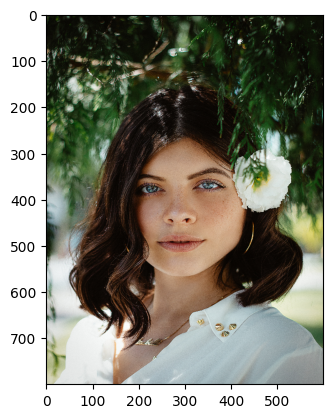

In [8]:
image = cv2.imread(r"images/Sofia.jpg")
image = cv2.resize(image, (600, 800))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = np.ascontiguousarray(image)
H, W = image.shape[:2]

plt.imshow(image)

## Face Mesh

In [9]:
with facemesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
) as face_mesh:
    results = face_mesh.process(image)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [10]:
print(bool(results.multi_face_landmarks))

True


In [11]:
landmark_0 = results.multi_face_landmarks[0].landmark[0]
print(landmark_0)

landmark_0_x = landmark_0.x * W
landmark_0_y = landmark_0.y * H
landmark_0_z = landmark_0.z * W

print()
print("X:", landmark_0_x)
print("Y:", landmark_0_y)
print("Z:", landmark_0_z)
print()
print("Total Length of '.landmark':", len(results.multi_face_landmarks[0].landmark))

x: 0.48349323868751526
y: 0.6055516004562378
z: -0.051833853125572205


X: 290.09594321250916
Y: 484.44128036499023
Z: -31.100311875343323

Total Length of '.landmark': 468


## Visualization 

In [12]:
def plot(
    *,
    img_dt,
    img_eye_lmks=None,
    img_eye_lmks_chosen=None,
    face_landmarks=None,
    ts_thickness=1,
    ts_circle_radius=2,
    lmk_circle_radius=3,
    name="1",
):
    image_drawing_tool = img_dt

    img_eye_lmks = img_dt.copy() if img_eye_lmks is None else img_eye_lmks
    img_eye_lmks_chosen = (
        img_dt.copy() if img_eye_lmks_chosen is None else img_eye_lmks_chosen
    )

    connections_drawing_spec = drawing.DrawingSpec(
        thickness=ts_thickness, circle_radius=ts_circle_radius, color=(255, 255, 255)
    )

    fig = plt.figure(figsize=(20, 15))
    fig.set_facecolor("white")

    drawing.draw_landmarks(
        image=image_drawing_tool,
        landmark_list=face_landmarks,
        connections=facemesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=connections_drawing_spec,
    )

    landmarks = face_landmarks.landmark

    for landmark_idx, landmark in enumerate(landmarks):
        if landmark_idx in all_idxs:
            pred_cord = denorm_coordinates(landmark.x, landmark.y, W, H)
            cv2.circle(img_eye_lmks, pred_cord, lmk_circle_radius, (255, 255, 255), -1)

        if landmark_idx in all_chosen_idxs:
            pred_cord = denorm_coordinates(landmark.x, landmark.y, W, H)
            cv2.circle(
                img_eye_lmks_chosen, pred_cord, lmk_circle_radius, (255, 255, 255), -1
            )

    plt.subplot(1, 3, 1)
    plt.title("Face Mesh Tessellation", fontsize=18)
    plt.imshow(image_drawing_tool)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("All eye landmarks", fontsize=18)
    plt.imshow(img_eye_lmks)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_eye_lmks_chosen)
    plt.title("Chosen landmarks", fontsize=18)
    plt.axis("off")
    plt.show()
    plt.close()

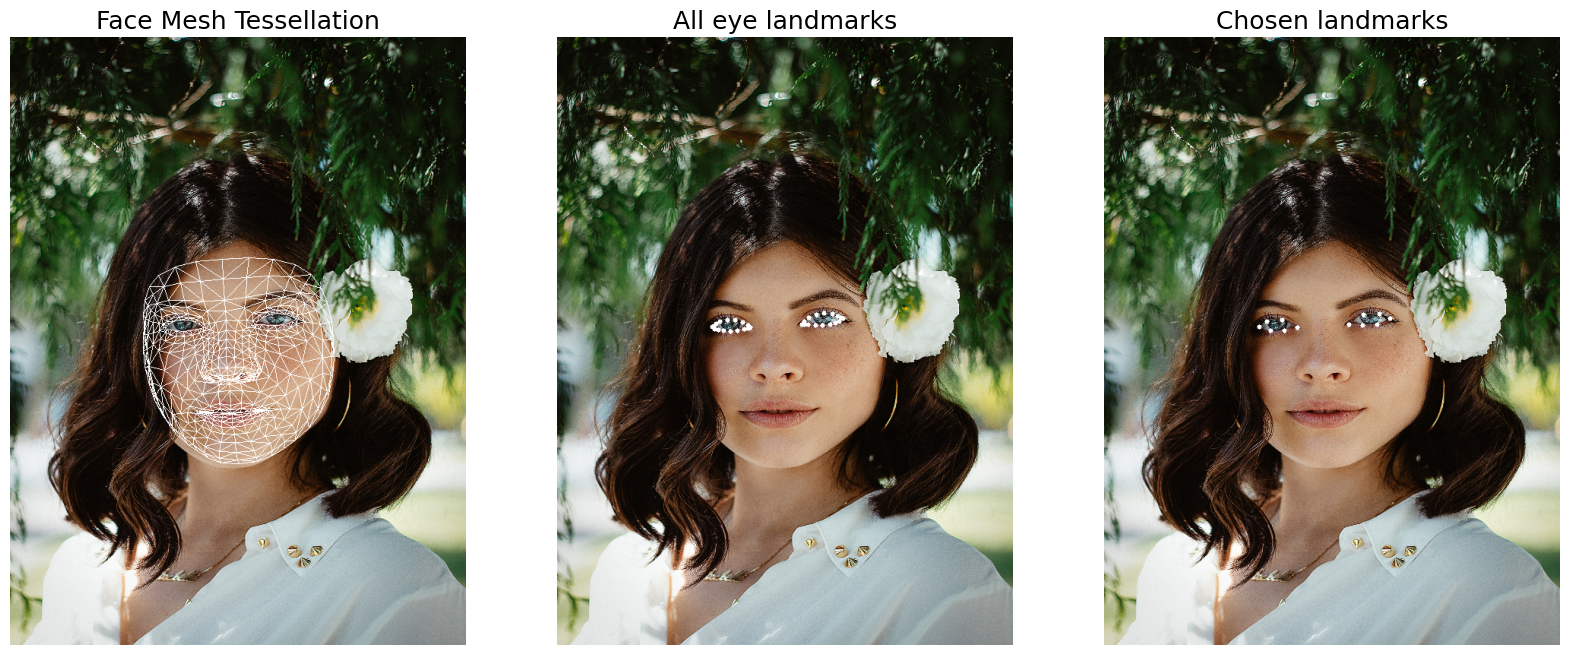

In [13]:
if results.multi_face_landmarks:
    for face_id, face_landmarks in enumerate(results.multi_face_landmarks):
        plot(img_dt=image.copy(), face_landmarks=face_landmarks)

## Eye Aspect Ratio (EAR)

Paper: http://vision.fe.uni-lj.si/cvww2016/proceedings/papers/05.pdf

### Functions to calculate EAR

#### Euclidean distance

In [14]:
def distance(pt1, pt2):
    dist = sum([(i - j) ** 2 for i, j in zip(pt1, pt2)]) ** 0.5
    return dist

#### Calc EAR 

In [15]:
def get_ear(landmarks, refer_idxs, frame_width, frame_height):
    try:
        coords_pts = []
        for i in refer_idxs:
            lm = landmarks[i]
            coord = denorm_coordinates(lm.x, lm.y, frame_width, frame_height)
            coords_pts.append(coord)

        P2_P6 = distance(coords_pts[1], coords_pts[5])
        P3_P5 = distance(coords_pts[2], coords_pts[4])
        P1_P4 = distance(coords_pts[0], coords_pts[3])

        ear = (P2_P6 + P3_P5) / (2.0 * P1_P4)
    except:
        ear = 0.0
        coords_pts = None

    return ear, coords_pts

#### Cal Avg EAR

In [16]:
def calculate_avg_ear(landmarks, left_eye_idxs, right_eye_idxs, image_w, image_h):
    left_ear, left_lm_coords = get_ear(landmarks, left_eye_idxs, image_w, image_h)
    right_ear, right_lm_coords = get_ear(landmarks, right_eye_idxs, image_w, image_h)

    Avg_EAR = (left_ear + right_ear) / 2.0

    return Avg_EAR, (left_lm_coords, right_lm_coords)

## Testing EAR

#### Loading images

In [17]:
image_eye_open = cv2.imread("images/Sofia.jpg")[..., ::-1]
image_eye_open = cv2.resize(image_eye_open, (600, 800))
image_eye_closed = cv2.imread("images/Saul.jpg")[..., ::-1]
image_eye_closed = cv2.resize(image_eye_closed, (600, 800))

#### Plotting  

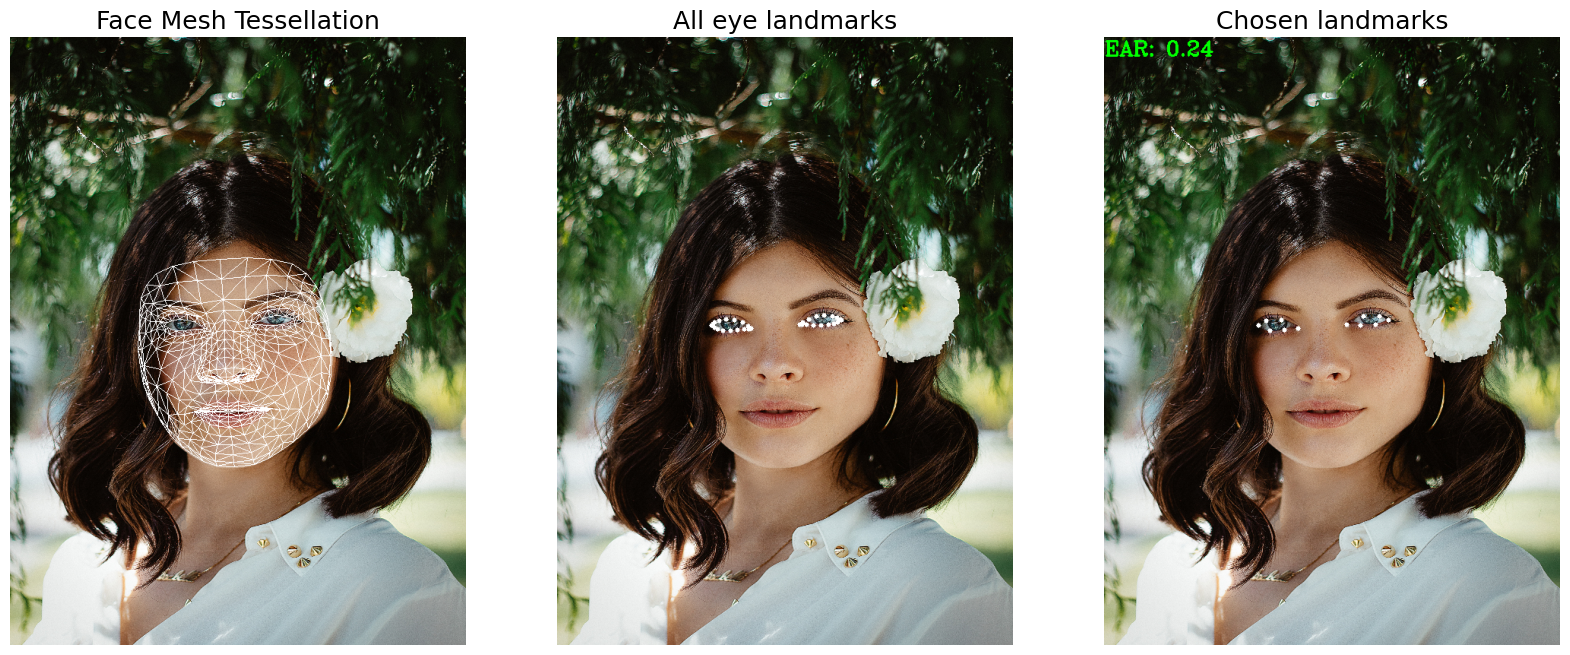

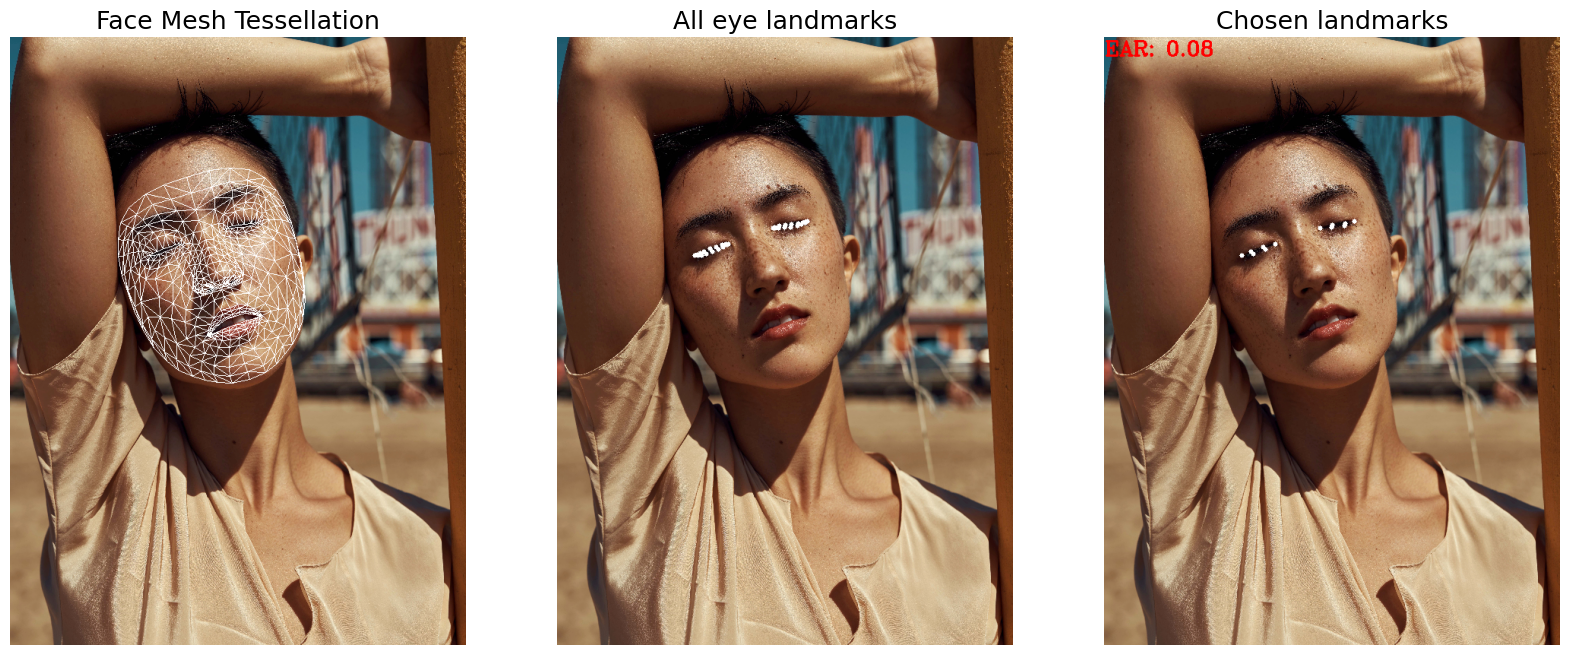

In [20]:
color_EAR = (0, 255, 0)

for idx, image in enumerate([image_eye_open, image_eye_closed]):

    image = np.ascontiguousarray(image)
    H, W = image.shape[:2]

    custom_chosen_lmk_image = image.copy()

    with facemesh.FaceMesh(refine_landmarks=True) as face_mesh:
        results = face_mesh.process(image).multi_face_landmarks

        if results:
            for face_id, face_landmarks in enumerate(results):
                landmarks = face_landmarks.landmark
                EAR, _ = calculate_avg_ear(
                    landmarks, chosen_left_eye_idxs, chosen_right_eye_idxs, W, H
                )
                
                if EAR < 0.2:
                    color_EAR = (255, 0, 0)

                cv2.putText(
                    custom_chosen_lmk_image,
                    f"EAR: {round(EAR, 2)}",
                    (1, 24),
                    cv2.FONT_HERSHEY_COMPLEX,
                    0.9,
                    color_EAR,
                    2,
                )

                plot(
                    img_dt=image.copy(),
                    img_eye_lmks_chosen=custom_chosen_lmk_image,
                    face_landmarks=face_landmarks,
                    ts_thickness=1,
                    ts_circle_radius=3,
                    lmk_circle_radius=3,
                )